 # **HW3: Performance Analysis of Sparse Data Storage Implementations**

**Academic Year:** 2024/2025


# SPARSE MATRICES:
Sparse data storage is important in many applications where matrices often contain a significant proportion of
zero values. In this project we want to analyze the performance
of different sparse matrix storage formats (COO, CSR, CSC,
DOK and LIL) using the MovieLens dataset. We evaluated
and compared matrix creation, matrix-vector multiplication, and
Singular Value Decomposition (SVD) times as well as memory
usage for each format


Main Steps:



1.  Loading the dataset and preprocessing.
2.  Implementation of Storage Methods
3. Measuring the time of common operations.
4. Visualizing the results.
5. Sparse matrix reordering: impact con computational times

## **Loading the dataset and preprocessing**

To compare the performances of different sparse matrices
format we used the **MovieLens** dataset.
The rows of that dataset correspond to users, the columns
correspond to movies, and the entries denote the ratings.

In [ ]:
import pandas as pd
import numpy as np
import copy
from scipy.sparse import coo_matrix, dok_matrix, lil_matrix,  csr_matrix, csc_matrix
from scipy.sparse.linalg import svds
from scipy.sparse.csgraph import connected_components
from scipy.sparse.csgraph import reverse_cuthill_mckee
import matplotlib.pyplot as plt
from time import time
pd.options.display.max_columns = 10
pd.options.display.max_rows = 10

In [ ]:
# Path to the CSV file
movielens_path = "/content/movielens.csv"

# Loading the full dataset as a DataFrame
movielens_full = pd.read_csv(movielens_path, sep=';')
movielens_full.columns = ['user_id', 'movie_id', 'rating', 'timestamp']

# Normalize user_id and movie_id to start from 0
movielens_full['user_id'] -= 1
movielens_full['movie_id'] -= 1

# Pivot the table and fill missing values with 0
movielens_df0 = movielens_full.pivot(index='user_id', columns='movie_id', values='rating')
movielens_df = movielens_df0.fillna(0)

# Display the resulting DataFrame
display(movielens_df)

movie_id,0,1,2,3,4,...,1677,1678,1679,1680,1681
user_id,,,,,,,,,,,
0,5.0,3.0,4.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0
1,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
4,4.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
938,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
939,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0
940,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Show the characteristics of the first 5 columns of the dataset
movielens_df.describe().iloc[:, :5]

movie_id,0,1,2,3,4
count,943.000000,943.000000,943.000000,943.000000,943.000000
mean,1.858961,0.445387,0.289502,0.786850,0.301166
std,2.042084,1.166107,0.966513,1.543481,0.992792
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


**Sparsity** of a matrix refers to the proportion of elements in the matrix that are zero. In other words, a matrix is considered sparse if most of its elements are zero, and it is called dense when most of its elements are non-zero.

The sparsity of a matrix is quantified by the fraction of zero entries compared to the total number of elements in the matrix.

In [ ]:
#Compute the sparsity of the rating matrix
num_users = movielens_df.shape[0]
num_items = movielens_df.shape[1]
non_zero_elements= np.count_nonzero(movielens_df)
sparsity = 1- (non_zero_elements / (num_users * num_items))
print(f'number of users: {num_users}, number of items: {num_items}')
print(f'matrix sparsity: {sparsity:f}')

number of users: 943, number of items: 1682
matrix sparsity: 0.936954


Since the matrix has a sparsity of **93%**, it is highly beneficial to adopt specialized storage formats that efficiently handle sparse matrices, as these formats can significantly reduce memory usage and improve computational efficiency by storing only the non-zero elements.

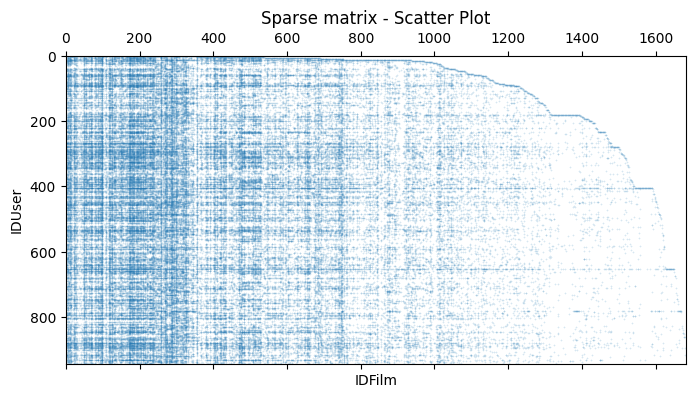

In [ ]:
#Scatter plot to visualize the sparsity of the matrix
plt.figure(figsize=(8, 4))
plt.spy(movielens_df, markersize=0.05, aspect='auto')
plt.title("Sparse matrix - Scatter Plot")
plt.xlabel("IDFilm")
plt.ylabel("IDUser")
plt.show()

From the scatter-plot above we can visualize the high sparsity of the matrix. We can also tell that the non-zero values don't follow a particular pattern.
Most users have only rated a small quantity of the movies.
Darker points in the plot could represents both the movies that have been rated by many user or the users that rated many movies.\
Let's zoom in on the matrix to better visualize its sparsity and observe the distribution of non-zero elements more clearly.



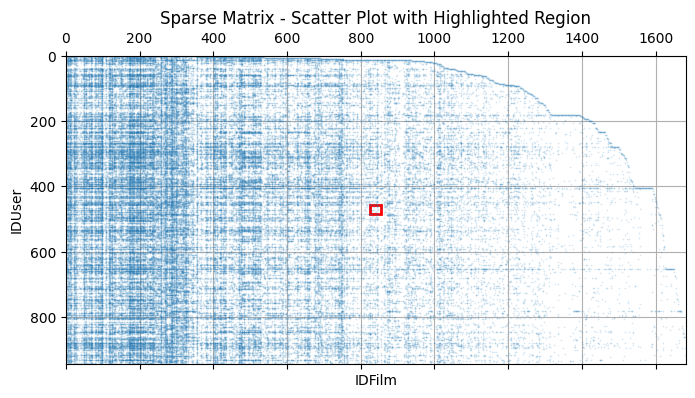

In [ ]:
plt.figure(figsize=(8, 4))
plt.spy(movielens_df, markersize=0.05, aspect='auto')

#center coordinates
center_row = movielens_df.shape[0] // 2
center_col = movielens_df.shape[1] // 2

row_start, row_end = center_row - 15, center_row + 15
col_start, col_end = center_col - 15, center_col + 15


rect = plt.Rectangle((col_start, row_start), col_end - col_start, row_end - row_start,
                     linewidth=2, edgecolor='red', facecolor='none', linestyle='-')
plt.gca().add_patch(rect)


plt.title("Sparse Matrix - Scatter Plot with Highlighted Region")
plt.xlabel("IDFilm")
plt.ylabel("IDUser")
plt.grid(True)
plt.show()


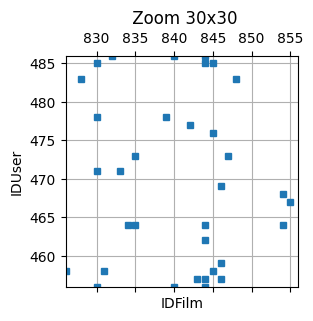

In [ ]:
plt.figure(figsize=(3, 3))
plt.spy(movielens_df, markersize=5, aspect='auto')
plt.xlim(col_start, col_end)
plt.ylim(row_start, row_end)
plt.title(" Zoom 30x30")
plt.xlabel("IDFilm")
plt.ylabel("IDUser")
plt.grid(True)
plt.show()

The above graph is related to the sparsity of the central values of the matrix. The distribution does not show a clear pattern and appears random.


## **Implementation of Storage Methods - CREATION AND MEMORY REQUIRED**

In [ ]:
#Initializing an empty dictionary to store the execution times of different operations on sparse matrices
#to compare creation, conversion and operation time
times = {}

#Initializes a dictionary that will be used to store information about the memory usage of different
#format of sparse matrix
memory={}

data=movielens_df.values
# this code extracts the values from the movielens_df DataFrame and assigns them to
#a variable called data that is a numpy array and it will be the starting point
#of storage format creation

**Coordinate List (COO)**: This format stores the row
indices, column indices, and non-zero values in three
separate arrays. It is simple to implement and efficient
for constructing sparse matrices but not optimal for
arithmetic operations.

In [ ]:
#Coordinate format (COO)
start = time()
coo = coo_matrix(data)
times["COO Creation"] = time() - start
print("JR-row indices:", coo.row)
print("JC-col indices:", coo.col)
print("AA-data values:", coo.data)


data_memory = coo.data.nbytes
row_memory = coo.row.nbytes
col_memory = coo.col.nbytes


total_memory = data_memory + row_memory + col_memory
print('')
print(f"Required memory:")
print(f"  Non-zero values (`AA-data`): {data_memory / 1024:.2f} KB")
print(f"  Row indices (`JR-row`): {row_memory / 1024:.2f} KB")
print(f"  Column indices (`JC-col`): {col_memory / 1024:.2f} KB")
print(f"  Total: {total_memory / 1024:.2f} KB")
memory["COO"] = total_memory / 1024


#the memory sizes is divided by 1024 to convert the memory usage from bytes to kilobytes (KB)

JR-row indices: [  0   0   0 ... 942 942 942]
JC-col indices: [   0    1    2 ... 1187 1227 1329]
AA-data values: [5. 3. 4. ... 3. 3. 3.]

Required memory:
  Non-zero values (`AA-data`): 781.24 KB
  Row indices (`JR-row`): 390.62 KB
  Column indices (`JC-col`): 390.62 KB
  Total: 1562.48 KB




---



**Compressed Sparse Row (CSR)**: CSR stores the non-zero
values, column indices, and row pointers in three arrays.
It is efficient for row slicing, and operations focusing on accessing rows like multiplying the matrix by a column vector (A * x).

In [ ]:
#Compressed Sparse Row format (CSR)
start = time()
csr = csr_matrix(data)
times["CSR Creation"] = time() - start
print("AA-data:", csr.data)
print("IA-indptr:", csr.indptr[:10],"...")
#IA is an array of lenght m+1 (944), but we consider only the first 10 values to a easier visualization
print("JA-indices:", csr.indices)


print('')

data_memory = csr.data.nbytes
indices_memory = csr.indices.nbytes
indptr_memory = csr.indptr.nbytes

total_memory = data_memory + indices_memory + indptr_memory

print(f"CSR Memory usage:")
print(f"  Non-zero values (`AA-data`): {data_memory / 1024:.2f} KB")
print(f"  Column indices (`JA-indices`): {indices_memory / 1024:.2f} KB")
print(f"  Row pointer (`IA-indptr`): {indptr_memory / 1024:.2f} KB")
print(f"  Total: {total_memory / 1024:.2f} KB\n")
memory["CSR"] = total_memory/ 1024

AA-data: [5. 3. 4. ... 3. 3. 3.]
IA-indptr: [   0  272  334  388  412  587  798 1201 1260 1282] ...
JA-indices: [   0    1    2 ... 1187 1227 1329]

CSR Memory usage:
  Non-zero values (`AA-data`): 781.24 KB
  Column indices (`JA-indices`): 390.62 KB
  Row pointer (`IA-indptr`): 3.69 KB
  Total: 1175.55 KB



In [ ]:
#IA=csr.indptr is an array of lenght (rows + 1) where IA[i+1]-IA[i] is
#the number of the non-zero entries in row i

#PROOF
print(csr.indptr[2]-csr.indptr[1])
print(np.count_nonzero(movielens_df.iloc[1, :]))

#The only difference from the theory is that IA[1] = 0 instead of being equal to 1

62
62


The first advantage of CSR is that the length of the third vector decreases with respect to the COO schema. In fact, we store 2 * Nz for the AA and JA vectors, but only (m+1) elements are needed for the IA vector. This can significantly improve memory usage in certain cases.

In particular, there is a memory saving if:

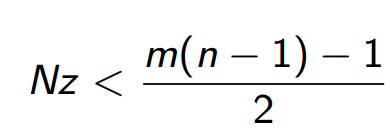



In [ ]:
n, m = movielens_df.shape
val=(m*(n-1)-1)/2
display(non_zero_elements,val)


99999

792221.5

Consequently, in the graph of the required memory, the CSR format will have a better value compared to the COO format.



---



**Compressed Sparse Column (CSC)**: Similar to CSR, CSC
stores the non-zero values, row indices, and column
pointers. It is more efficient for operations that focus
on columns, such as matrix-vector where the matrix is multiplied by a column vector from the left (x * A) or a row vector from the right (A * x.T).

In [ ]:
#Compressed Sparse Column format(CSC)
start = time()
csc = csc_matrix(data)
times["CSC Creation"] = time() - start
print("AA-data:", csc.data)
print("IA-indptr:", csc.indptr[:10],"...") #we consider only the first 10 values to a easier visualization
print("JA-indices:", csc.indices)


print('')
data_memory = csc.data.nbytes
indices_memory = csc.indices.nbytes
indptr_memory = csc.indptr.nbytes

total_memory = data_memory + indices_memory + indptr_memory

print(f"CSC Memory usage:")
print(f"  Non-zero values (`AA-data`): {data_memory / 1024:.2f} KB")
print(f"  Row indices (`JA-indices`): {indices_memory / 1024:.2f} KB")
print(f"  Column pointer (`IA-indptr`): {indptr_memory / 1024:.2f} KB")
print(f"  Total: {total_memory / 1024:.2f} KB\n")
memory["CSC"] = total_memory/ 1024


AA-data: [5. 4. 4. ... 2. 3. 3.]
IA-indptr: [   0  452  583  673  882  968  994 1386 1605 1904] ...
JA-indices: [  0   1   4 ... 862 895 915]

CSC Memory usage:
  Non-zero values (`AA-data`): 781.24 KB
  Row indices (`JA-indices`): 390.62 KB
  Column pointer (`IA-indptr`): 6.57 KB
  Total: 1178.44 KB



In [ ]:
len(csc.indptr)

1683

In [ ]:
#IA=csc.indptr is an array of lenght (columns + 1) where IA[i+1]-IA[i] is
#the number of the non-zero entries in column i

#PROOF
print(csc.indptr[2]-csc.indptr[1])
print(np.count_nonzero(movielens_df.iloc[:, 1]))

#The only difference from the theory is that IA[1] = 0 instead of being equal to 1

131
131




---



**Dictionary of Keys (DOK)**: DOK stores the non-zero
values in a dictionary, where the keys are the coordinates
of the non-zero elements. This format is highly flexible
and easy to update but is not efficient in terms of memory
usage for large matrices.


In the case of the DOK (Dictionary of Keys)  and List of Lists (LIL) data structure, unlike other representations such as CSC (Compressed Sparse Column), COO (Coordinate Format), and CSR (Compressed Sparse Row), there are no specific methods available to directly calculate memory usage. Therefore, it is essential to understand how the nbytes attribute in NumPy works to determine the memory consumed by DOK and LIL, such that it can be comparable with the other.

The NumPy **ndarray.nbytes()** function return the total bytes consumed by the elements of the array by multiplying the shape of the array and the size of one array element.

So, to obtain an accurate assessment of the memory usage of a DOK matrix and a LIL matrix, we need to verify the data types used to store the non-zero elements, as the space occupied by each element depends on its data type (size of one array element).

In [ ]:
#COO
print("Data type in coo.data:", coo.data.dtype)
print("Data type in coo.row:", coo.row.dtype)
print("Data type in coo.col:", coo.col.dtype)

print("----------------------------------------------")

#CSR
print("Data type in csr.data:", csr.data.dtype)
print("Data type in csr.indptr:", csr.indptr.dtype)
print("Data type in csr.indices:", csr.indices.dtype)

print("----------------------------------------------")

#CSC
print("Data type in csc.data:", csc.data.dtype)
print("Data type in csc.indptr:", csc.indptr.dtype)
print("Data type in csc.indices:", csc.indices.dtype)

Data type in coo.data: float64
Data type in coo.row: int32
Data type in coo.col: int32
----------------------------------------------
Data type in csr.data: float64
Data type in csr.indptr: int32
Data type in csr.indices: int32
----------------------------------------------
Data type in csc.data: float64
Data type in csc.indptr: int32
Data type in csc.indices: int32


Following these results, to achieve a consistent representation, we consider the indices in the DOK (Dictionary of Keys) structure as int32, which means that the memory used by the indices will be multiplied by 4 bytes. Similarly, we treat the values in the DOK structure as float64, leading to a multiplication factor of 8 bytes for the memory occupied by the values.

In [ ]:
#Dictionary Of Keys format (DOK)
start = time()
dok=dok_matrix(data)
times["DOK Creation"] = time() - start

#print(dok) too many rows we decide to print a smaller output
count = 0
for (row, col), value in dok.items():
    print(f"({row}, {col})   {value}")
    count += 1
    if count == 3:
        break
print(".....")
all_items = list(dok.items())
for (row, col), value in all_items[-3:]:
    print(f"({row}, {col}) {value}")


print('')
data_memory = dok.nnz * 8  # float64
index_memory = dok.nnz * 4 * 2  # 4 bytes for row and 4 bytes for column indices (2 indices per value in int32)

total_memory = data_memory + index_memory

print(f"DOK Memory usage:")
print(f"  Total: {total_memory / 1024:.2f} KB\n")
memory["DOK"] = total_memory/ 1024

(0, 0)   5.0
(0, 1)   3.0
(0, 2)   4.0
.....
(942, 1187) 3.0
(942, 1227) 3.0
(942, 1329) 3.0

DOK Memory usage:
  Total: 1562.48 KB





---



**List of Lists (LIL):** LIL stores each row as a list of column
indices and their corresponding values. It is easy to
modify and update but is less efficient for large matrices
and matrix-vector multiplication.

In [ ]:
#List of Lists format (LIL)
start = time()
lil=lil_matrix(data)
times["LIL Creation"] = time() - start


#When working with a sparse matrix in the LIL (List of Lists) format, it is internally stored as a list of lists,
#where each row contains the indices of the non-zero columns and the associated values. However, when you print the
#matrix, it is displayed by default as a generic representation of the elements (similar to the COO format).

n_rows = 5
n_cols = 4

for i, (cols, vals) in enumerate(zip(lil.rows, lil.data), start=1):
    if i > n_rows:
        break
    limited_cols = cols[:n_cols]
    limited_vals = vals[:n_cols]
    elements_to_print = list(zip(limited_cols, limited_vals))
    if len(cols) > n_cols:
        elements_to_print.append('...')
        elements_to_print.append((cols[-1], vals[-1]))

    print(f"L{i-1}: {elements_to_print}")

print("...")
print("")

nnz = lil.nnz  # Number of non-zero elements
num_rows = lil.shape[0]
value_memory = nnz * 8  # Memory for values: assuming float64 (8 bytes per value)
index_memory = nnz * 4  # # Memory for column indices: assuming int32 (4 bytes per index)


# Total memory
#It should also be considered the memory required to store the list and tuples as data structures.
#However, here we are limiting the evaluation to the space required for the values themselves.

total_memory = value_memory + index_memory

print(f"LIL Memory usage:")
print(f"  Non-zero values (`data`): {value_memory / 1024:.2f} KB")
print(f"  Column indices: {index_memory / 1024:.2f} KB")
print(f"  Total: {total_memory / 1024:.2f} KB\n")

memory["LIL"] = total_memory/ 1024


L0: [(0, 5.0), (1, 3.0), (2, 4.0), (3, 3.0), '...', (271, 3.0)]
L1: [(0, 4.0), (9, 2.0), (12, 4.0), (13, 4.0), '...', (315, 5.0)]
L2: [(180, 4.0), (244, 1.0), (257, 2.0), (259, 4.0), '...', (354, 3.0)]
L3: [(10, 4.0), (49, 5.0), (209, 3.0), (257, 5.0), '...', (361, 5.0)]
L4: [(0, 4.0), (1, 3.0), (16, 4.0), (20, 3.0), '...', (456, 1.0)]
...

LIL Memory usage:
  Non-zero values (`data`): 781.24 KB
  Column indices: 390.62 KB
  Total: 1171.86 KB





---



**Diagonal Storage (DIA)**: DIA stores only the diagonals of
the matrix. It is highly efficient for diagonally dominant
matrices and operations that only involve those diagonals

The DIA format is highly efficient only for matrices with non-zero elements concentrated along the diagonals. If the matrix is not structured in this way, the advantages of the format are limited.

The following code blocks provide a check to determine if the use of the DIA format is appropriate based on the density of the diagonals.

In [ ]:
#MAIN DIAGONAL DENSITY

diagonal = [data[i][i] for i in range(len(data))]
non_zero_count = sum(1 for x in diagonal if x != 0)
density = non_zero_count / len(diagonal)
print(f"Main diagonal density is: {density * 100:.2f}%")

Main diagonal density is: 9.97%


In [ ]:
# DENSITY OF THE 100 MAIN DIAGONALS

def is_dia_appropriate_sparse(matrix, threshold=0.8, bandwidth_limit=50):

    sparse_matrix = coo_matrix(matrix.values)
    row, col = sparse_matrix.nonzero()
    total_nonzeros = sparse_matrix.nnz  # Total number of non-zero elements

    # Count non-zero elements for each diagonal
    diagonal_counts = {}
    for r, c in zip(row, col):
        offset = c - r
        diagonal_counts[offset] = diagonal_counts.get(offset, 0) + 1

    diagonal_counts = {k: v for k, v in diagonal_counts.items() if abs(k) <= bandwidth_limit}

    # Calculate diagonal density
    diagonal_nonzeros = sum(diagonal_counts.values())
    density = diagonal_nonzeros / total_nonzeros

    print(f"Total non-zero elements: {total_nonzeros}")
    print(f"Non-zero elements on considered diagonals: {diagonal_nonzeros}")
    print(f"Main 100 diagonals density is: {density:.2%}")


    return density >= threshold

result = is_dia_appropriate_sparse(movielens_df)
print("----------------------------------------------")
if not result:
    print("The DIA format is not appropriate for the given matrix.")
else:
    print("The DIA format is appropriate for the given matrix.")


Total non-zero elements: 99999
Non-zero elements on considered diagonals: 9248
Main 100 diagonals density is: 9.25%
----------------------------------------------
The DIA format is not appropriate for the given matrix.


We excluded also the **ELLPACK-Itpack** and **MSR**/**MSC** formats from the analysis due to compatibility issues. The fixed-width structure of the ELLPACK method did not allow for implementing SVD, making it challenging to compare the performance of the two methods. The MSR (Modified Sparse Row) format is efficient only for square matrices where the diagonal contains only non-zero values. Given the distribution of non-zero entries in the MovieLens dataset, MSR was not suitable for our needs. The same reasoning applies to the MSC (Modified Sparse Column) format, which similarly relies on specific structural properties of the matrix that the dataset does not exhibit.


In [ ]:
display(times)
display(memory)

{'COO Creation': 0.050374507904052734,
 'CSR Creation': 0.06280779838562012,
 'CSC Creation': 0.02559828758239746,
 'DOK Creation': 0.2865438461303711,
 'LIL Creation': 0.06103110313415527}

{'COO': 1562.484375,
 'CSR': 1175.55078125,
 'CSC': 1178.4375,
 'DOK': 1562.484375,
 'LIL': 1171.86328125}

The values obtained from these code blocks are presented above and will be discussed in the following section.

##**Measuring the time of common operations**

In [ ]:
matrix=[coo,csr,csc,dok,lil]
matrix_names=['COO','CSR','CSC','DOK','LIL']
multiplication_times=[]
decomposition_times = []
reconstruction_times=[]

### 1) MATRIX-BY-VECTOR MULTIPLICATION

To evaluate the different operation times taken by various sparse matrix storage formats, the following code calculates the weighted average of ratings based on the number of ratings made by the user. This approach provides a comprehensive analysis of how each storage format affects the performance of matrix-by-vector multiplication, offering insights into the efficiency of different data structures in handling sparse matrices. By assessing the execution times alongside the weighted ratings, we can gain a clearer understanding of the trade-offs involved in using different sparse matrix representations.
This computation allows for a comparison between the average movie ratings and the average ratings adjusted based on user experience.



In [ ]:
#ASSIGN SCORE TO USER BASE ON THE COUNT OF RATING (MAX 2, MIN 0)
movies_rated_per_user = movielens_df0.notna().sum(axis=1)

min_val = movies_rated_per_user.min()
max_val = movies_rated_per_user.max()

movies_rated_per_user_normalized = 2 * (movies_rated_per_user - min_val) / (max_val - min_val)

# Display the result
print('Number of movies rated by each user')
print(movies_rated_per_user)
print('----------------------------------')
print('Number of movies rated by each user normalized in a range [2,0]')
print(movies_rated_per_user_normalized)

Number of movies rated by each user
user_id
0      272
1       62
2       54
3       24
4      175
      ... 
938     49
939    107
940     22
941     79
942    168
Length: 943, dtype: int64
----------------------------------
Number of movies rated by each user normalized in a range [2,0]
user_id
0      0.702929
1      0.117155
2      0.094840
3      0.011158
4      0.432357
         ...   
938    0.080893
939    0.242678
940    0.005579
941    0.164575
942    0.412831
Length: 943, dtype: float64


In [ ]:
min_time= float('inf')
for matr, matrix_name in zip(matrix, matrix_names):
    matrix_transposed = matr.T
    start_time = time()
    result = matrix_transposed.dot(movies_rated_per_user_normalized)  # Matrix multiplication
    multiplication_time = time() - start_time  # Calculate the time taken
    multiplication_times.append(multiplication_time)  # Store the time
    if multiplication_time < min_time:
      min_time = multiplication_time
      min_matrix_name = matrix_name  # Store the name of the matrix format

print(min_matrix_name)

CSC


Since we would obtain similar results to complete the analysis, we decide to proceed only with the CSC (Compressed Sparse Column) format, as its structure is expected to be the most efficient for this operation.

In [ ]:
result = csc.T.dot(movies_rated_per_user_normalized)

#Count how many users rated each movie
user_counts = (csc != 0).sum(axis=0).A1
#.A1 attribute is used to convert the resulting sparse matrix

# Normalize the scores by dividing by the weighted sum to the number of raters
result_normalized = np.divide(result, user_counts, where=user_counts != 0)

result_series = pd.Series(result_normalized)
sorted_result = result_series.sort_values(ascending=False)

#Get the ID of the movie with the highest score
highest_score_movie_id = sorted_result.index[0]

# Print the ID of the movie with the highest score and the score itself
print(f"The ID of the movie with the highest score is: {highest_score_movie_id}")

print(f"The highest score is: {sorted_result.iloc[0]}")

print("----------------------------------------------------")

#Compare this result with the one obtained without weight

grouped = movielens_full.groupby('movie_id')['rating'].agg(['sum', 'count'])
grouped['average_rating'] = grouped['sum'] / grouped['count']
grouped.reset_index(inplace=True)

sorted_grouped = grouped.sort_values(by='average_rating', ascending=False)


highest_score_movie_id = sorted_grouped.iloc[0]['movie_id']
highest_average_score = sorted_grouped.iloc[0]['average_rating']

print(f"The ID of the movie with the highest score is: {highest_score_movie_id}")
print(f"The highest score is: {highest_average_score}")


The ID of the movie with the highest score is: 813
The highest score is: 8.591352859135286
----------------------------------------------------
The ID of the movie with the highest score is: 1200.0
The highest score is: 5.0


In [ ]:
display(movielens_full[movielens_full['movie_id'] == 1200])
print("--------------------------------------------------")
display(movielens_full[movielens_full['movie_id'] == 813])

,user_id,movie_id,rating,timestamp
78007,89,1200,5,891383687


--------------------------------------------------


,user_id,movie_id,rating,timestamp
6518,12,813,5,886302261


In [ ]:
print("Number of movies rated by userID 89")
display(f'{movies_rated_per_user[89]} - Normalized: {movies_rated_per_user_normalized[89]}')
print('----------------------------------')
print("Number of movies rated by userID 12")
display(f'{movies_rated_per_user[12]} - Normalized: {movies_rated_per_user_normalized[12]}')



Number of movies rated by userID 89


'300 - Normalized: 0.7810320781032078'

----------------------------------
Number of movies rated by userID 12


'636 - Normalized: 1.7182705718270572'

The simple average approach calculates the average rating by summing all ratings for a movie and dividing by the total number of ratings. It doesn't differentiate between ratings from users who have rated many movies and those who have rated only a few.

The weighted average approach instead, relate to user experience by assigning weights to users based on the number of movies they have rated. Users who have rated more movies receive higher weights and their ratings are considered more trustworthy.

The difference in results is due to the inclusion of user experience in the weighted average calculation.

MovieID 1200 was rated with a score of 5.0 by a single user (ID 89), resulting in the highest recommendation value in the average-based analysis (sum of ratings divided by the number of ratings), but its weighted average decreases due to the low number of ratings from that user.

In contrast, MovieID 813, receive a higher score because it was rated by a more experienced user (ID 12), who has rated a larger number of movies, surpassing MOVIEID 1200.

The weighted approach favors experienced users, while the simple average may favor movies with fewer but high ratings.



### 2) ANALYZING OPERATION TIMES IN COLLABORATIVE FILTERING METHODS

**Collaborative filtering** is based on an intuitive idea we use
in everyday life. When looking for a new movie to watch,
we often ask friends for recommendations, especially those
who share our tastes. The goal of collaborative filtering is to
predict how much a user will appreciate an item they haven’t
yet rated, based on historical preference data collected from a
community of users. An approach to collaborative filtering is Model-Based Collaborative Filtering that employs statistical or machine learning models to discover and leverage hidden patterns in the data. These
models predict user preferences for unseen items by training
on historical interaction data between users and items.
One of the most well-known techniques in this
category is **SVD matrix decomposition**.


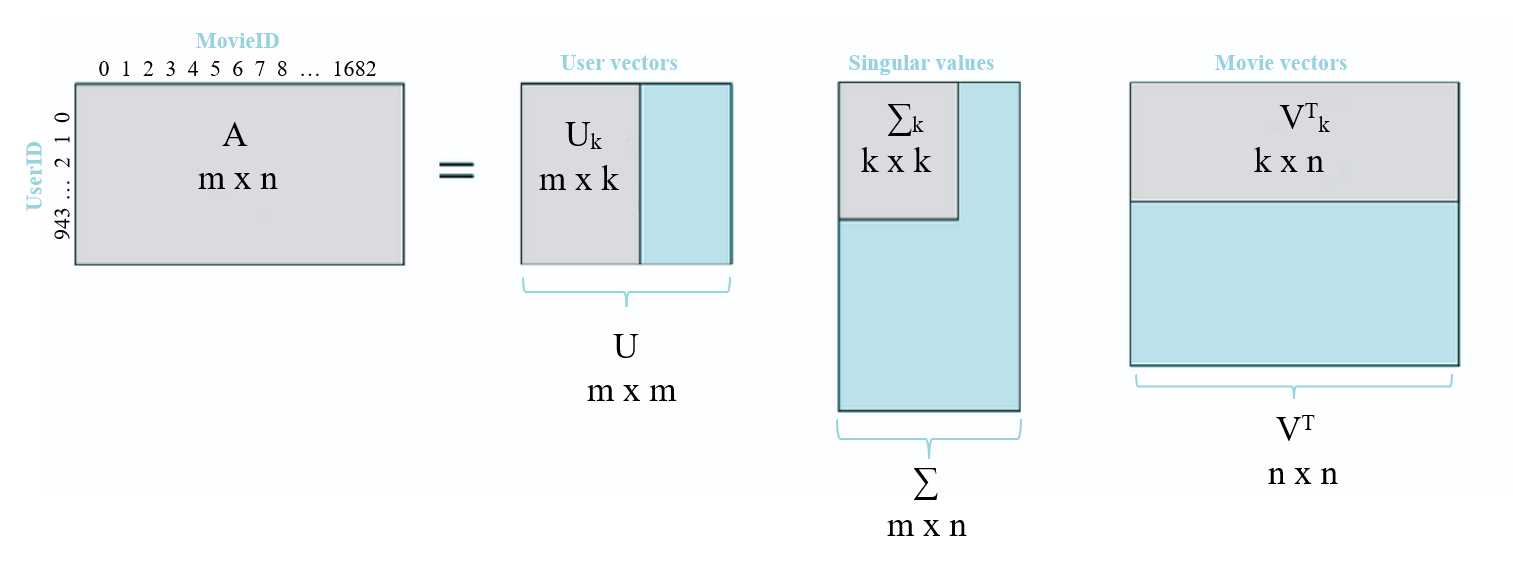

In [ ]:
#Load the dataset containing film information
movie_path = "/content/item.csv"

# Loading the full dataset as a dataframe
movie_df= pd.read_csv(movie_path,sep='|', header=None)
movie_df.columns = ['movie_id', 'movie_title', 'release_date', 'video_release_date',
              'IMDb URL','unknown','Action','Adventure', 'Animation',
              'Children', 'Comedy','Crime','Documentary','Drama','Fantasy'
              ,'Film-Noir','Horror','Musical','Mystery','Romance', 'Sci-Fi',
              'Thriller' ,'War','Western']
# Normalize movie_id to start from 0
movie_df['movie_id'] -= 1
movie_df.set_index('movie_id', inplace=True)
display(movie_df.iloc[:,:4])

,movie_title,release_date,video_release_date,IMDb URL
movie_id,,,,
0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...
3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...
4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995)
...,...,...,...,...
1677,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...
1678,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...
1679,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998)


The **predicted rating** is given by considering the rate of the recostructed matrix with **k=20**.
The recommendation is generated by ignoring movies that the user has already seen and sorting the
predictions to obtain the top **5** movies that a specific user is likely to enjoy the most.

In [ ]:
def apply_svd(matrix):
    # Compute SVD decomposition
    start_time = time()
    matrix = matrix.astype(np.float32)
    #svds (scipy.sparse.linalg.svds): to compute SVD decomposition of a sparse matrix
    U, sigma, Vt = svds(matrix, k=20)
    decomposition_time = time() - start_time
    print(f"SVD decomposition time: {decomposition_time:.4f} seconds")
    # Reconstruct the matrix
    start_time = time()
    approx_matrix = np.dot(U, np.dot(np.diag(sigma), Vt))
    reconstruction_time = time() - start_time
    print(f"Matrix reconstruction time: {reconstruction_time:.4f} seconds")
    return approx_matrix, decomposition_time, reconstruction_time, Vt


def recommend_movies(approx_matrix, movie_df, movielens_df, user_id, n_recommendations):
    user_ratings = approx_matrix[user_id]
    # Create a DataFrame for predicted ratings for easier manipulation
    predicted_ratings_df = pd.DataFrame(user_ratings, columns=['predicted_rating'])
    # Get the user's actual ratings
    actual_ratings = movielens_df.loc[user_id]
    actual_ratings = actual_ratings[actual_ratings != 0.0]

    # Exclude movies that the user has already rated
    recommendations = predicted_ratings_df[~predicted_ratings_df.index.isin(actual_ratings.index)]

    # Return the movies that have not been rated, ordered by predicted rating
    top_recommendations = recommendations.nlargest(n_recommendations, 'predicted_rating')
    for index, row in top_recommendations.iterrows():
        movie_id = index + 1
        movie_title = movie_df.loc[movie_id, 'movie_title']
        print(f"Movie ID: {movie_id}, Title: {movie_title}, Predicted Rating: {row['predicted_rating']:.2f}")
    return top_recommendations


def apply_svd_and_recommend(matrix, matrix_type, user_id, movie_df, original_ratings, num_recommendations):
    # SVD
    approx_matrix, decomposition_time, reconstruction_time, vt = apply_svd(matrix)
    # RECOMMEND A MOVIE TO A SPECIFIC USER
    recommendations = recommend_movies(approx_matrix, movie_df, original_ratings, user_id, num_recommendations)
    return decomposition_time, reconstruction_time


# Apply SVD and recommendation to each
for matrix, matrix_name in zip(matrix, matrix_names):
    np.random.seed(78)
    print(f"Storage format: {matrix_name}")
    user_id = np.random.randint(0, 943)
    decomposition_time, reconstruction_time = apply_svd_and_recommend(matrix, matrix, user_id, movie_df=movie_df, original_ratings=movielens_df, num_recommendations=5)
    decomposition_times.append(decomposition_time)
    reconstruction_times.append(reconstruction_time)
    print()


Storage format: COO
SVD decomposition time: 0.2646 seconds
Matrix reconstruction time: 0.0191 seconds
Movie ID: 98, Title: Snow White and the Seven Dwarfs (1937), Predicted Rating: 3.93
Movie ID: 427, Title: Harold and Maude (1971), Predicted Rating: 2.67
Movie ID: 288, Title: Evita (1996), Predicted Rating: 2.61
Movie ID: 272, Title: Heat (1995), Predicted Rating: 2.25
Movie ID: 183, Title: Army of Darkness (1993), Predicted Rating: 2.05

Storage format: CSR
SVD decomposition time: 0.1219 seconds
Matrix reconstruction time: 0.0166 seconds
Movie ID: 98, Title: Snow White and the Seven Dwarfs (1937), Predicted Rating: 3.93
Movie ID: 427, Title: Harold and Maude (1971), Predicted Rating: 2.67
Movie ID: 288, Title: Evita (1996), Predicted Rating: 2.61
Movie ID: 272, Title: Heat (1995), Predicted Rating: 2.25
Movie ID: 183, Title: Army of Darkness (1993), Predicted Rating: 2.05

Storage format: CSC
SVD decomposition time: 0.1865 seconds
Matrix reconstruction time: 0.0098 seconds
Movie ID: 

##**VISUALIZING THE RESULT**

The main objective of this section is to provide an intuitive representation of key findings that will aid in understanding the behavior and performance of the various sparse matrix storage formats. Using plots, we can easily compare and contrast the effects of different techniques of storage.
The detailed discussion and interpretation of these results will follow in the report.

###CREATION TIMES

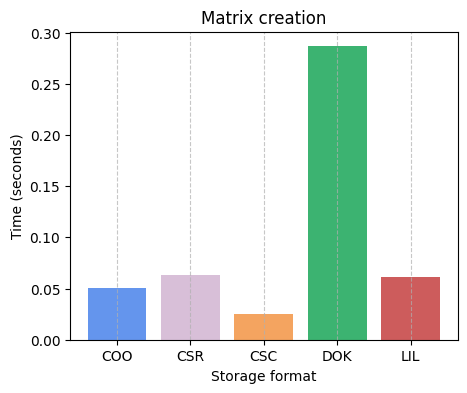

In [ ]:
color=['cornflowerblue', 'thistle', 'sandybrown', 'mediumseagreen', "indianred"]
creation_values = [times["COO Creation"],times["CSR Creation"],times["CSC Creation"], times["DOK Creation"], times["LIL Creation"]]
plt.figure(figsize=(5, 4))
plt.bar(matrix_names, creation_values, color=color)
plt.ylabel("Time (seconds)")
plt.xlabel("Storage format")
plt.title("Matrix creation")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



###MEMORY REQUIRED

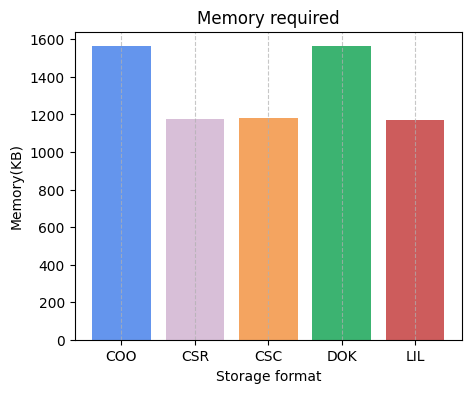

In [ ]:
memory_values = memory.values()
plt.figure(figsize=(5, 4))
plt.bar(matrix_names, memory_values, color=color)
plt.xlabel("Storage format")
plt.ylabel("Memory(KB)")
plt.title("Memory required")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

###MATRIX-BY-VECTOR MULTIPLICATION TIMES

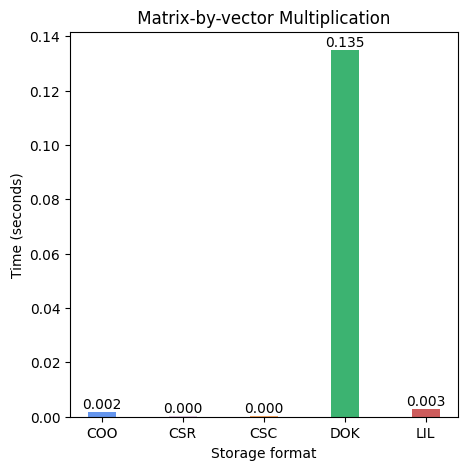

In [ ]:
bar_width = 0.35
fig, ax = plt.subplots(figsize=(5, 5))
index = np.arange(len(matrix_names))
bar2 = ax.bar(index, multiplication_times, bar_width,color=color)

ax.set_xlabel('Storage format')
ax.set_ylabel('Time (seconds)')
ax.set_title(' Matrix-by-vector Multiplication ')
ax.set_xticks(index)
ax.set_xticklabels(matrix_names)
for i, bar in enumerate(bar2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        multiplication_times[i] + 0.0002,
        f'{multiplication_times[i]:.3f}',
        ha='center', va='bottom', fontsize=10, color='black'
    )
plt.show()



In [ ]:
print(multiplication_times)

[0.0017342567443847656, 0.0003666877746582031, 0.0003376007080078125, 0.1349194049835205, 0.0029685497283935547]


###SVD DECOMPOSITION TIMES

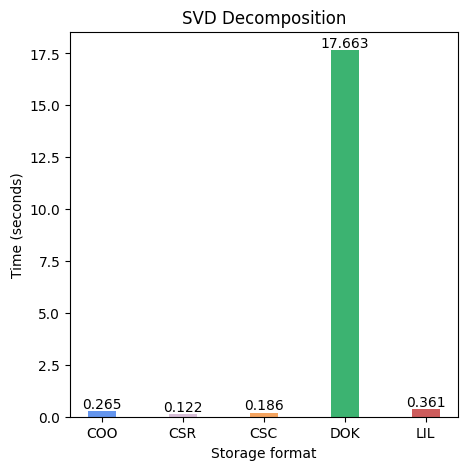

In [ ]:
bar_width = 0.35
index = np.arange(len(matrix_names))

fig, ax = plt.subplots(figsize=(5, 5))
bar1 = ax.bar(index, decomposition_times, bar_width, color=color)

ax.set_xlabel("Storage format")
ax.set_ylabel('Time (seconds)')
ax.set_title('SVD Decomposition')
ax.set_xticks(index)
ax.set_xticklabels(matrix_names)
ax.set_xticklabels(matrix_names)
for i, bar in enumerate(bar1):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        decomposition_times[i],
        f'{decomposition_times[i]:.3f}',
        ha='center', va='bottom', fontsize=10, color='black'
    )
plt.show()


###TOTAL EXECUTION TIMES

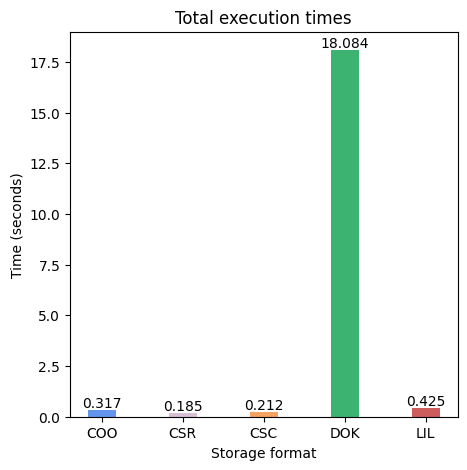

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

total_times = np.array(creation_values) + np.array(decomposition_times) + np.array(multiplication_times)
bar2 = ax.bar(index, total_times , bar_width, color=color)

ax.set_xlabel('Storage format')
ax.set_ylabel('Time (seconds)')
ax.set_title('Total execution times')
ax.set_xticks(index)
ax.set_xticklabels(matrix_names)
for i, bar in enumerate(bar2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        total_times[i] + 0.0002,
        f'{total_times[i]:.3f}',
        ha='center', va='bottom', fontsize=10, color='black'
    )
plt.show()

##**SPARSE MATRIX REORDERING: IMPACT ON COMPUTATIONAL TIMES**

The structure of sparse matrices requires optimized strategies for both storage and computation. Reordering, which takes advantage of the arrangement of non-zero entries, is one of the most effective techniques for enhancing performance.

Several algorithms and strategies have been developed to modify the pattern of a sparse matrix, enhancing performance.




*   **Level-set orderings**



* **Independent set orderings**



The following codes demonstrate the efficiency of applying these reordering techniques. Since the algorithms are applied to square matrices, a
943×943 dataset has been considered for comparison. The implementation will be performed on both the original matrix and the reordered matrix, using the CSR (Compressed Sparse Row) storage format.

In [ ]:
#SQUARE MATRIX: 943×943 dataset
movielens_dfsquare= movielens_df.iloc[:943, :943]
display(movielens_dfsquare)

movie_id,0,1,2,3,4,...,938,939,940,941,942
user_id,,,,,,,,,,,
0,5.0,3.0,4.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0
1,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
4,4.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
938,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0
939,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0
940,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0


###**Level-set orderings**

In [ ]:
#ORIGINAL MATRIX
csr2 = csr_matrix(movielens_dfsquare)

#REORDERED MATRIX

#reverse_cuthill_mckee(graph, symmetric_mode=False)
#Takes as input a CSR or CSC matrix and returns the permutation array that orders a sparse matrix in Reverse-Cuthill McKee ordering.

#Define the permutation
perm = reverse_cuthill_mckee(csr2, symmetric_mode=False)
#Compute the trasformation
reordered_matrix = csr2[perm, :][:, perm]




print(f"Permutation array: {perm[:5]}...")
print("")
print("Original matrix:\n", csr2.toarray())
print("")
print("Reordered matrix:\n", reordered_matrix.toarray())


Permutation array: [570 699 561  79  35]...

Original matrix:
 [[5. 3. 4. ... 0. 0. 0.]
 [4. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [5. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 5. 0. ... 1. 0. 5.]]

Reordered matrix:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 3. 0.]]


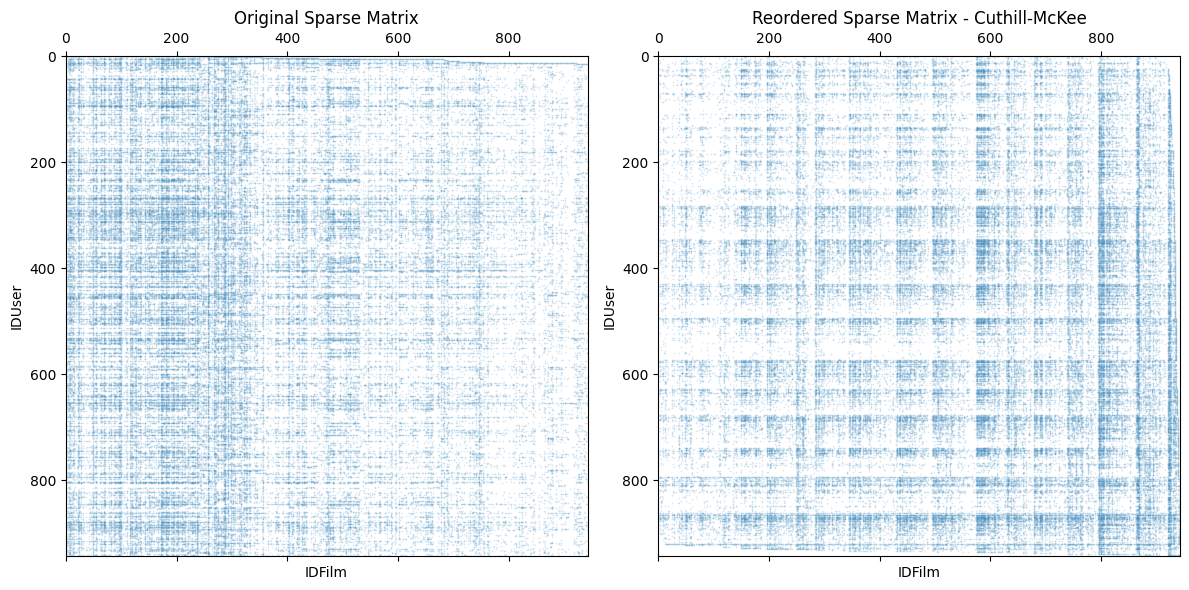

In [ ]:
#PLOT TO COMPARE THE PATTERN OF THE TWO MATRICES

plt.figure(figsize=(12, 6))

#  original matrix
plt.subplot(1, 2, 1)
plt.spy(movielens_dfsquare, markersize=0.05, aspect='auto')
plt.title("Original Sparse Matrix")
plt.xlabel("IDFilm")
plt.ylabel("IDUser")

#  reordered matrix
plt.subplot(1, 2, 2)
plt.spy(reordered_matrix, markersize=0.05, aspect='auto')
plt.title("Reordered Sparse Matrix - Cuthill-McKee")
plt.xlabel("IDFilm")
plt.ylabel("IDUser")


plt.tight_layout()
plt.show()

The reordered matrix, processed
using the Reverse Cuthill-McKee algorithm, exhibits a more
banded and ordered structure.

###**Independent set orderings**

In [ ]:

def independent_set_ordering(matrix):
    #Adjacency graph
    matrix_sparse = csr_matrix(matrix.values)
    adjacency_matrix = matrix_sparse @ matrix_sparse.T

    #Greedy algorithm to compute the Indipendent Set
    n = matrix.shape[0]
    marked = np.zeros(n, dtype=bool)
    independent_set = []

    for i in range(n):
        if not marked[i]:
            independent_set.append(i)
            neighbors = adjacency_matrix[i].indices  # Ottieni i vicini
            marked[i] = True
            marked[neighbors] = True

    # Remaining indices
    remaining = [i for i in range(n) if i not in independent_set]

    # Permutation array as a composition of the Indipendent Set and the remaining indices
    perm = np.array(independent_set + remaining)

    # Reordered matrix using iloc for position-based indexing
    reordered_matrix_is = matrix.iloc[perm, :].iloc[:, perm]
    return perm, reordered_matrix_is

# Application of the Independent Set Ordering
perm_is, reordered_matrix_is = independent_set_ordering(movielens_dfsquare)

print(f"Permutation array: {perm_is[:5]}...")
print("")
print("Original matrix:\n", csr2.toarray())
print("")
print("Reordered matrix:")
print(reordered_matrix_is)

Permutation array: [0 1 2 3 4]...

Original matrix:
 [[5. 3. 4. ... 0. 0. 0.]
 [4. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [5. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 5. 0. ... 1. 0. 5.]]

Reordered matrix:
movie_id  0    1    2    3    4    ...  938  939  940  941  942
user_id                            ...                         
0         5.0  3.0  4.0  3.0  3.0  ...  0.0  0.0  0.0  0.0  0.0
1         4.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0
2         0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0
3         0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0
4         4.0  3.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0
...       ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...
938       0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0
939       0.0  0.0  0.0  2.0  0.0  ...  0.0  0.0  0.0  0.0  0.0
940       5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0
941       0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0
942 

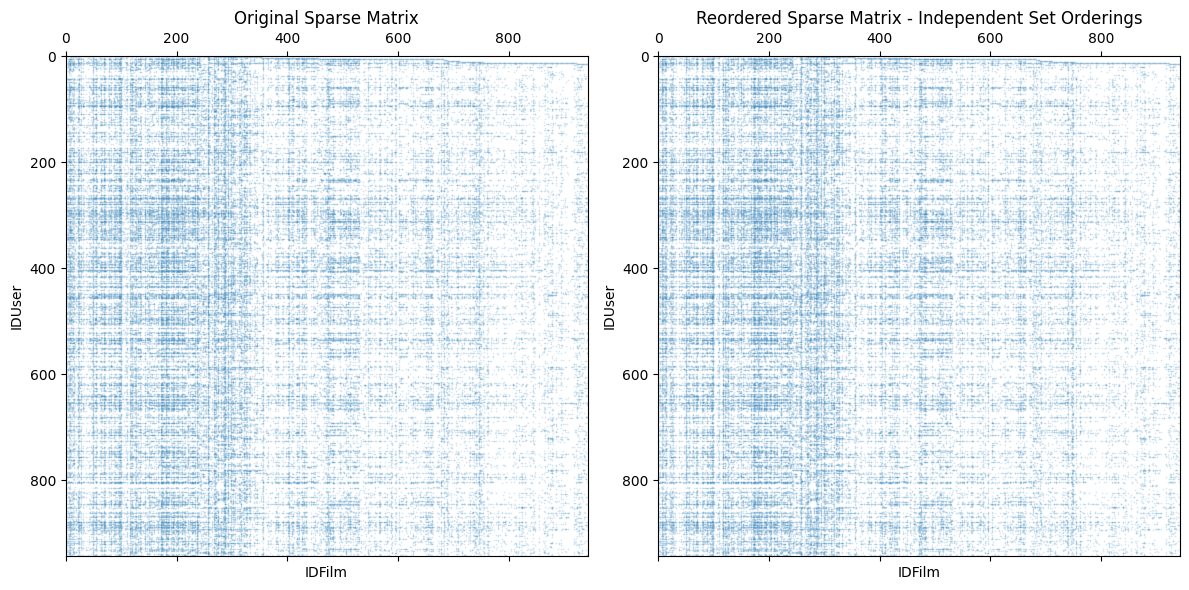

In [ ]:
plt.figure(figsize=(12, 6))

# original matrix
plt.subplot(1, 2, 1)
plt.spy(movielens_dfsquare, markersize=0.05, aspect='auto')
plt.title("Original Sparse Matrix")
plt.xlabel("IDFilm")
plt.ylabel("IDUser")

# reordered matrix
plt.subplot(1, 2, 2)
plt.spy(reordered_matrix_is, markersize=0.05, aspect='auto')
plt.title("Reordered Sparse Matrix - Independent Set Orderings")
plt.xlabel("IDFilm")
plt.ylabel("IDUser")


plt.tight_layout()
plt.show()

There are not so many differences in the pattern.

###Performance Comparison Between Original and Reordered Matrices

In [ ]:
#Time creation comparison

#Level-set orderings
start = time()
coo_reordered_cm =coo_matrix(reordered_matrix)
time_coo_reordered_cm = time() - start
print(f"Creation time (Cuthill-McKee): {time_coo_reordered_cm:.4f} seconds")


#Independent set orderings
start = time()
coo_reordered_is= coo_matrix(reordered_matrix_is)
time_coo_reordered_is = time() - start
print(f"Creation time (Independent Set): {time_coo_reordered_is:.4f} seconds")

#Reduces square matrix 943x943
start = time()
coo_reduced = coo_matrix(movielens_dfsquare)
time_coo_reduced = time() - start
print(f"Creation time (Original matrix): {time_coo_reduced:.4f} seconds")

Creation time (Cuthill-McKee): 0.0025 seconds
Creation time (Independent Set): 0.0285 seconds
Creation time (Original matrix): 0.0158 seconds


In [ ]:
#MATRIX BY VECTOR MULTIPLICATION, to obtain a rating for each film
#based on the user's "experience"

#Level-set orderings
matrix_transposed = coo_reordered_cm.T
start_time = time()
result = matrix_transposed.dot(movies_rated_per_user_normalized)  # Matrix multiplication
multiplication_time_cm = time() - start_time  # Calculate the time taken
print(f"Multiplication time (Cuthill-McKee): {multiplication_time_cm:.4f} seconds")

#Independent set orderings
matrix_transposed = coo_reordered_is.T
start_time = time()
result = matrix_transposed.dot(movies_rated_per_user_normalized)  # Matrix multiplication
multiplication_time_is = time() - start_time  # Calculate the time taken
print(f"Multiplication time (Independet set): {multiplication_time_is:.4f} seconds")

#Reduces square matrix 943x943
matrix_transposed = coo_reduced.T
start_time = time()
result = matrix_transposed.dot(movies_rated_per_user_normalized)  # Matrix multiplication
multiplication_time_reduc= time() - start_time  # Calculate the time taken
print(f"Multiplication time (Original matrix): {multiplication_time_reduc:.4f} seconds")

Multiplication time (Cuthill-McKee): 0.0008 seconds
Multiplication time (Independet set): 0.0016 seconds
Multiplication time (Original matrix): 0.0004 seconds


In [ ]:
#SVD TO THE RECOMMENDATION OF 5 MOVIES

user_id=np.random.randint(0,943)

decomposition_time_reor_cm, reconstruction_time_reor_cm= apply_svd_and_recommend(coo_reordered_cm, '', user_id, movie_df=movie_df, original_ratings=movielens_df, num_recommendations=5)
print("------------------------------------------------------")
decomposition_time_red, reconstruction_time_red= apply_svd_and_recommend(coo_reordered_is, '', user_id, movie_df=movie_df, original_ratings=movielens_df, num_recommendations=5)
print("------------------------------------------------------")
decomposition_time_reor_is, reconstruction_time_reor_is= apply_svd_and_recommend(coo_reduced, '', user_id, movie_df=movie_df, original_ratings=movielens_df, num_recommendations=5)



SVD decomposition time: 0.4602 seconds
Matrix reconstruction time: 0.0062 seconds
Movie ID: 441, Title: Amityville Curse, The (1990), Predicted Rating: 4.82
Movie ID: 930, Title: Island of Dr. Moreau, The (1996), Predicted Rating: 4.79
Movie ID: 838, Title: Loch Ness (1995), Predicted Rating: 4.78
Movie ID: 633, Title: Microcosmos: Le peuple de l'herbe (1996), Predicted Rating: 4.65
Movie ID: 462, Title: Secret of Roan Inish, The (1994), Predicted Rating: 4.62
------------------------------------------------------
SVD decomposition time: 0.1947 seconds
Matrix reconstruction time: 0.0065 seconds
Movie ID: 294, Title: Breakdown (1997), Predicted Rating: 2.33
Movie ID: 742, Title: Crow: City of Angels, The (1996), Predicted Rating: 1.85
Movie ID: 25, Title: Brothers McMullen, The (1995), Predicted Rating: 1.82
Movie ID: 127, Title: Supercop (1992), Predicted Rating: 1.80
Movie ID: 282, Title: Emma (1996), Predicted Rating: 1.80
------------------------------------------------------
SVD de

Both reverse Cuthill-McKee and Independent Set Ordering change how the non-zero elements are arranged within the matrix. This alteration affects how the SVD algorithm decomposes the matrix, leading to variations in the resulting U, sigma, and Vt matrices. These differences, impact the reconstructed matrix and consequentally the relationships learned by the algorithm leading to generate different movie recommendations.
In this situation no significant differences were observed when using the independent set reordering, as the scatter plot also shows that the reordering effect was not very pronounced, while we observe different results using reverse Cuthill-McKee.



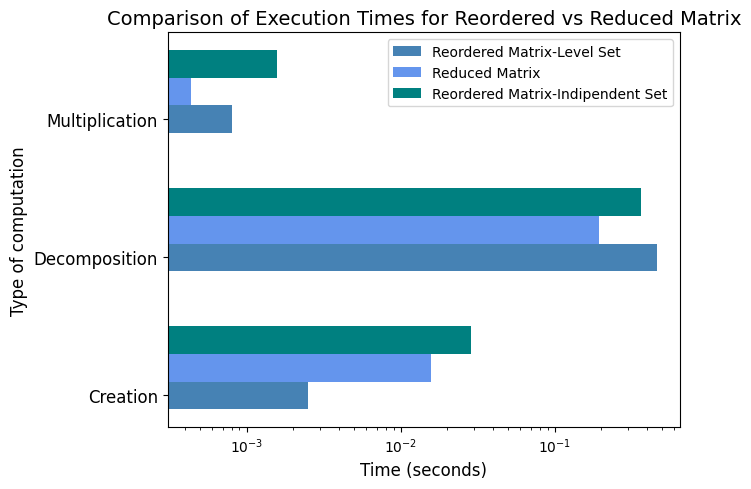

CREATION
COO_REORDERED-Level Set: 0.002489328384399414
COO_REORDERED-Indipendent Set: 0.028545618057250977
COO_REDUCED: 0.015761137008666992

DECOMPOSITION
COO_REORDERED-Level Set: 0.4602499008178711
COO_REORDERED-Indipendent Set: 0.3623781204223633
COO_REDUCED: 0.19467687606811523

MULTIPLICATION
COO_REORDERED-Level Set: 0.0008025169372558594
COO_REORDERED-Indipendent Set: 0.0015823841094970703
COO_REDUCED: 0.0004355907440185547



In [ ]:

labels = ['Creation','Decomposition', 'Multiplication']


reordered_times_cm = [time_coo_reordered_cm,decomposition_time_reor_cm,  multiplication_time_cm]
reordered_times_is = [time_coo_reordered_is,decomposition_time_reor_is,  multiplication_time_is]
reduced_times = [time_coo_reduced,decomposition_time_red,  multiplication_time_reduc]


x = np.arange(len(labels))
bar_width = 0.2
fig, ax = plt.subplots(figsize=(7, 5))

ax.barh(x, reordered_times_cm, bar_width, label='Reordered Matrix-Level Set', color='steelblue')
ax.barh(x + bar_width, reduced_times, bar_width, label='Reduced Matrix', color='cornflowerblue')
ax.barh(x + 2* bar_width, reordered_times_is, bar_width, label='Reordered Matrix-Indipendent Set', color='teal')



ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Type of computation', fontsize=12)
ax.set_title('Comparison of Execution Times for Reordered vs Reduced Matrix', fontsize=14)
ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=12)
ax.legend()

# Log Scale to better visualize the difference
ax.set_xscale('log')


plt.tight_layout()
plt.show()

for i in range(0,len(labels)):
  print(labels[i].upper())
  print(f'COO_REORDERED-Level Set: {reordered_times_cm[i]}')
  print(f'COO_REORDERED-Indipendent Set: {reordered_times_is[i]}')
  print(f'COO_REDUCED: {reduced_times[i]}')
  print('')

From the comparison of the times, we did not observe the expected improvements in case of reordering. The only improvement is seen in the slightly shorter decomposition times with the independent set reordering, but this is minimal and can be considered negligible. The reduced time for creating the level set reordering is of little significance, considering that it originates from a sparse matrix that still needs to be generated, and its creation time must be added to the reported times.